In [1]:
import matplotlib.pyplot as plt
from keras.layers import Dense,Activation
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
import pandas as pd

Training data Dimensions =  (60000, 28, 28)
Testing data Dimensions =  (60000, 28, 28)


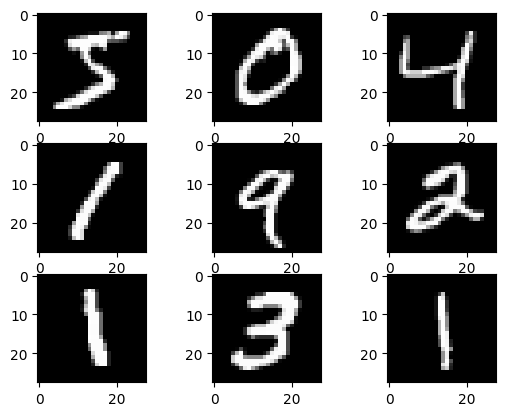

In [2]:
(trainX,trainY),(testX,testY)=mnist.load_data()
print('Training data Dimensions = ',trainX.shape)
print('Testing data Dimensions = ', trainX.shape)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(trainX[i],cmap=plt.get_cmap('gray'))
plt.show()

In [3]:
##############################################

trainX=trainX.reshape(60000,784) #28*28
testX=testX.reshape(10000,784) #28*28

trainY=to_categorical(trainY,10)
testY=to_categorical(testY,10)

In [4]:
###############################################

ann=Sequential([
    Dense(20,input_dim=784),
    Activation('sigmoid'),
    Dense(10),
    Activation('softmax')
])

c:\Python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
################################################

ann.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

summary=ann.fit(trainX,trainY,epochs=10,batch_size=100,verbose=1)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6306 - loss: 1.5091
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8171 - loss: 0.9717
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8480 - loss: 0.7679
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8644 - loss: 0.6524
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8713 - loss: 0.5831
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8761 - loss: 0.5347
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8813 - loss: 0.5038
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8857 - loss: 0.4755
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8888 - loss: 0.4488
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8889 - loss: 0.4387


313/313 - 2s - 5ms/step - accuracy: 0.8898 - loss: 0.4305
Testing Loss =  0.43051034212112427
Testing Accuracy =  0.8898000121116638


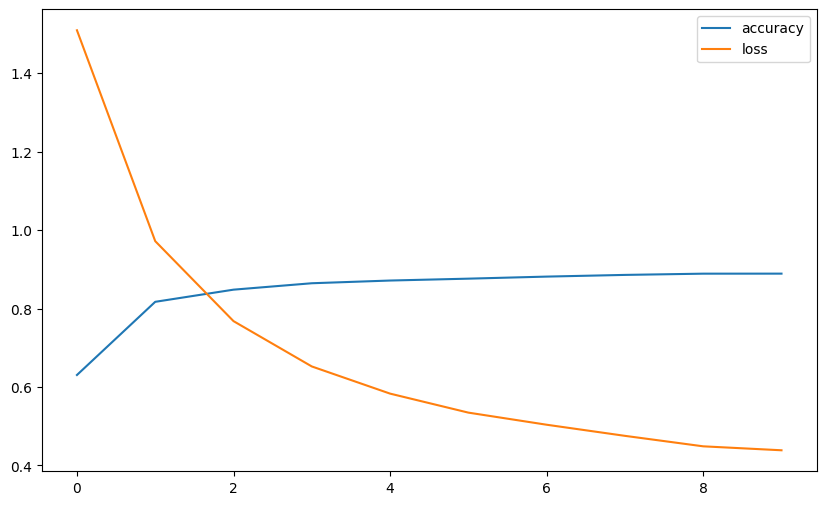

In [6]:
result=ann.evaluate(testX,testY,verbose=2)

print("Testing Loss = ",result[0])
print("Testing Accuracy = ",result[1])
pd.DataFrame(summary.history).plot(figsize=(10,6))
plt.show()